In [2]:
import pandas as pd
import numpy as np

# Lendo o arquivo direto da pasta de inputs do Kaggle
df = pd.read_csv('/kaggle/input/datasets/catherinerasgaitis/mxmh-survey-results/mxmh_survey_results.csv')

In [3]:
# Esse comando vai listar na tela o nome de todas as 33 colunas do seu arquivo original
print(df.columns.tolist())

['Timestamp', 'Age', 'Primary streaming service', 'Hours per day', 'While working', 'Instrumentalist', 'Composer', 'Fav genre', 'Exploratory', 'Foreign languages', 'BPM', 'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]', 'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]', 'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Music effects', 'Permissions']


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/datasets/catherinerasgaitis/mxmh-survey-results/mxmh_survey_results.csv')

# 2. Seleção de Variáveis (Ajustado 'Instrumentalist')
colunas_alvo = [
    'Age', 'Hours per day', 'While working', 'Fav genre', 
    'Instrumentalist', 'Composer', 'Music effects', 
    'Anxiety', 'Depression', 'Insomnia', 'OCD'
]
df_filtrado = df[colunas_alvo].copy()

# 3. Pré-processamento
df_filtrado['Age'] = df_filtrado['Age'].fillna(df_filtrado['Age'].median())
df_filtrado['Hours per day'] = df_filtrado['Hours per day'].fillna(df_filtrado['Hours per day'].mean())
df_filtrado = df_filtrado.dropna(subset=['While working', 'Music effects', 'Fav genre'])

# 4. Transformação (Dicionários de tradução)
traducao_binaria = {'Yes': 'Sim', 'No': 'Não'}
df_filtrado['While working'] = df_filtrado['While working'].map(traducao_binaria)
df_filtrado['Instrumentalist'] = df_filtrado['Instrumentalist'].map(traducao_binaria) # Ajustado aqui
df_filtrado['Composer'] = df_filtrado['Composer'].map(traducao_binaria)

traducao_efeitos = {'Improve': 'Melhora', 'No effect': 'Sem Efeito', 'Worsen': 'Piora'}
df_filtrado['Music effects'] = df_filtrado['Music effects'].map(traducao_efeitos)

# Renomeando as colunas finais para o relatório
df_filtrado.columns = [
    'Idade', 'Horas por dia', 'Musica no trabalho', 'Genero favorito', 
    'Toca instrumento', 'Compõe', 'Efeito da musica', 
    'Ansiedade', 'Depressão', 'Insônia', 'TOC'
]

print(f"Base tratada com sucesso! Total de registros: {df_filtrado.shape[0]} linhas.")
df_filtrado.head(15)

Base tratada com sucesso! Total de registros: 726 linhas.


,Idade,Horas por dia,Musica no trabalho,Genero favorito,Toca instrumento,Compõe,Efeito da musica,Ansiedade,Depressão,Insônia,TOC
2,18.0,4.0,Não,Video game music,Não,Não,Sem Efeito,7.0,7.0,10.0,2.0
3,61.0,2.5,Sim,Jazz,Não,Sim,Melhora,9.0,7.0,3.0,3.0
4,18.0,4.0,Sim,R&B,Não,Não,Melhora,7.0,2.0,5.0,9.0
5,18.0,5.0,Sim,Jazz,Sim,Sim,Melhora,8.0,8.0,7.0,7.0
6,18.0,3.0,Sim,Video game music,Sim,Não,Melhora,4.0,8.0,6.0,0.0
7,21.0,1.0,Sim,K pop,Não,Não,Melhora,5.0,3.0,5.0,3.0
8,19.0,6.0,Sim,Rock,Não,Não,Melhora,2.0,0.0,0.0,0.0
9,18.0,1.0,Sim,R&B,Não,Não,Melhora,2.0,2.0,5.0,1.0
10,18.0,3.0,Sim,Country,Sim,Não,Sem Efeito,7.0,7.0,4.0,7.0
11,19.0,8.0,Sim,EDM,Não,Não,Melhora,1.0,0.0,0.0,1.0


In [11]:
# Salva a tabela limpa em um novo arquivo CSV
df_filtrado.to_csv('seu_arquivo_limpo_excel.csv', sep=';', decimal=',', index=False)
print("Arquivo gerado com sucesso!")

Arquivo gerado com sucesso!


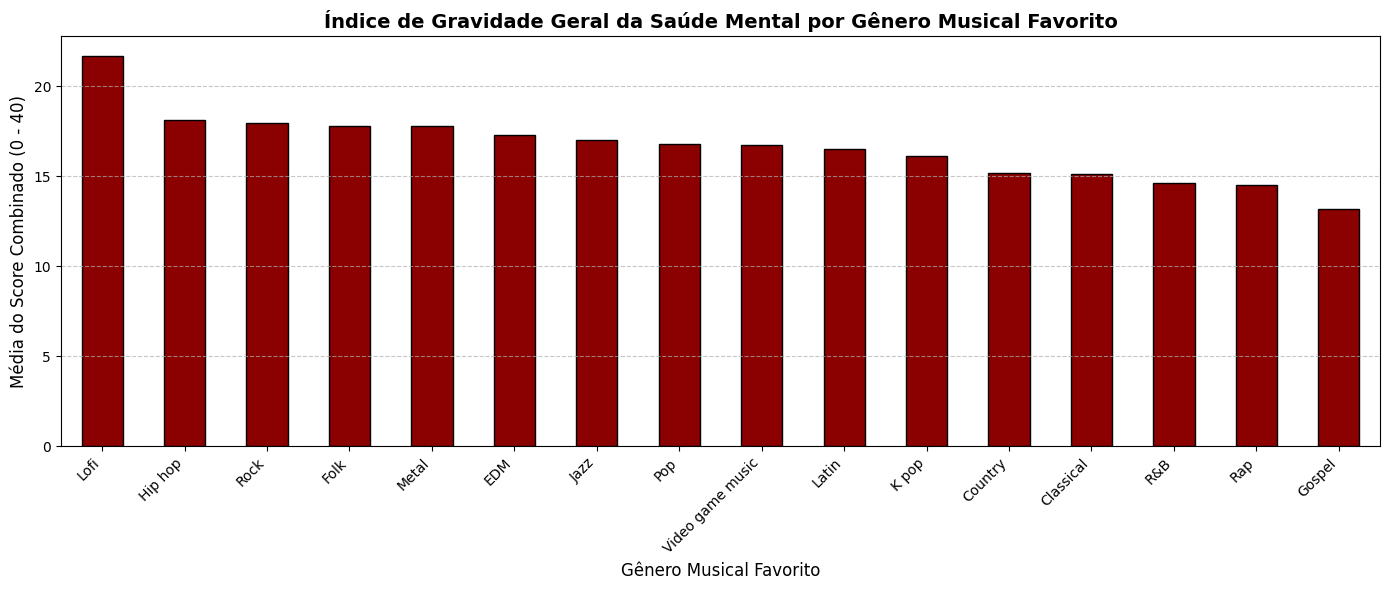

--- Arquivos salvos com sucesso na pasta Output! ---


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Criando o Índice de Gravidade Geral (Soma dos 4 transtornos)
df_filtrado['Gravidade Geral'] = df_filtrado[['Ansiedade', 'Depressão', 'Insônia', 'TOC']].sum(axis=1)

# 2. Agrupando por Gênero e calculando as médias
analise_q2 = df_filtrado.groupby('Genero favorito')[['Ansiedade', 'Depressão', 'Insônia', 'TOC', 'Gravidade Geral']].mean()

# [DOWNLOAD 1] SALVAR A TABELA DA Q2
# [DOWNLOAD 1] SALVAR A TABELA DA Q2 JÁ NO PADRÃO DO EXCEL BRASILEIRO
analise_q2.round(2).to_csv('tabela_saude_mental_por_genero.csv', sep=';', decimal=',', encoding='utf-8-sig')


# 3. Gerando o Gráfico de Barras para o Relatório
plt.figure(figsize=(14, 6))
analise_q2['Gravidade Geral'].sort_values(ascending=False).plot(kind='bar', color='darkred', edgecolor='black')

plt.title('Índice de Gravidade Geral da Saúde Mental por Gênero Musical Favorito', fontsize=14, fontweight='bold')
plt.xlabel('Gênero Musical Favorito', fontsize=12)
plt.ylabel('Média do Score Combinado (0 - 40)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# [DOWNLOAD 2] SALVAR O GRÁFICO EM ALTA RESOLUÇÃO
plt.savefig('grafico_gravidade_saude_mental.png', dpi=300, bbox_inches='tight')

# Exibe na tela do Kaggle para validação
plt.show()
print("--- Arquivos salvos com sucesso na pasta Output! ---")

In [7]:
display(analise_q2.round(2).sort_values(by='Gravidade Geral', ascending=False))

,Ansiedade,Depressão,Insônia,TOC,Gravidade Geral
Genero favorito,,,,,
Lofi,6.10,6.60,5.60,3.40,21.70
Hip hop,6.20,5.80,3.43,2.71,18.14
Rock,6.12,5.30,3.87,2.71,17.99
Folk,6.69,5.14,3.72,2.28,17.83
Metal,5.76,5.07,4.56,2.40,17.78
EDM,5.36,5.11,3.94,2.89,17.31
Jazz,5.90,4.50,3.85,2.80,17.05
Pop,6.07,4.49,3.37,2.86,16.79
Video game music,5.89,4.48,4.00,2.39,16.75


--- MÉDIAS DE SAÚDE MENTAL POR EFEITO PERCEBIDO ---


,Ansiedade,Depressão,Insônia,TOC,Gravidade Geral
Efeito da musica,,,,,
Melhora,6.04,4.85,3.74,2.71,17.35
Piora,6.76,7.18,4.53,3.12,21.59
Sem Efeito,5.10,4.40,3.63,2.38,15.51


<Figure size 1200x600 with 0 Axes>

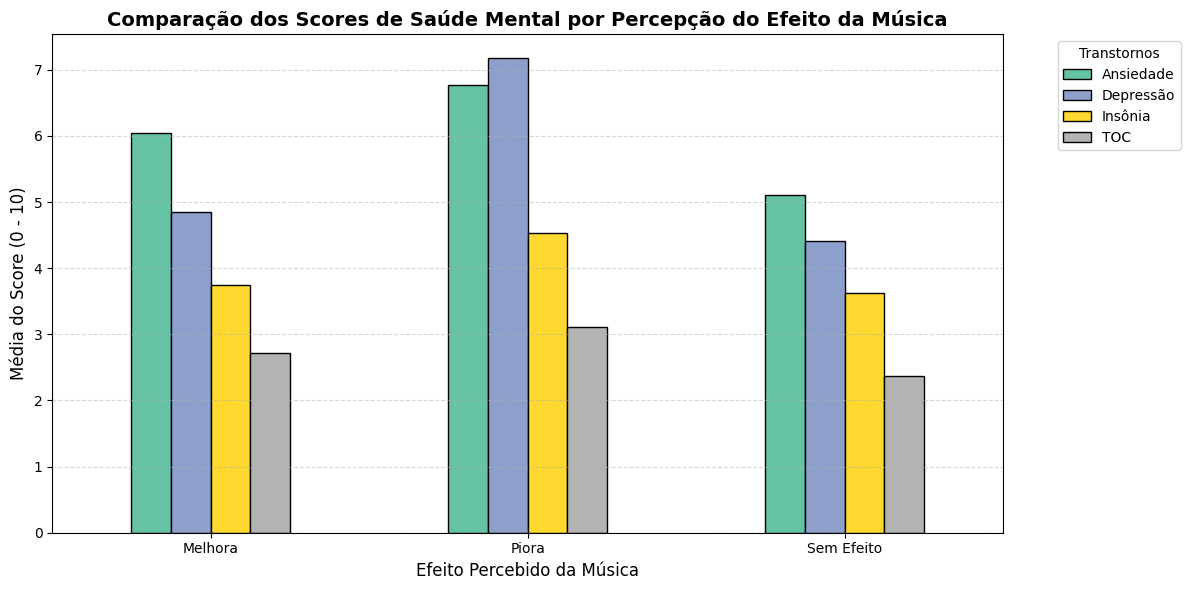

--- Tabela e Gráfico da Q4 salvos com sucesso na pasta Output! ---


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# PARTE 1: LEITURA E LIMPEZA (Garantindo as variáveis)
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/catherinerasgaitis/mxmh-survey-results/mxmh_survey_results.csv')

colunas_alvo = [
    'Age', 'Hours per day', 'While working', 'Fav genre', 
    'Instrumentalist', 'Composer', 'Music effects', 
    'Anxiety', 'Depression', 'Insomnia', 'OCD'
]
df_filtrado = df[colunas_alvo].copy()

df_filtrado['Age'] = df_filtrado['Age'].fillna(df_filtrado['Age'].median())
df_filtrado['Hours per day'] = df_filtrado['Hours per day'].fillna(df_filtrado['Hours per day'].mean())
df_filtrado = df_filtrado.dropna(subset=['While working', 'Music effects', 'Fav genre'])

traducao_efeitos = {'Improve': 'Melhora', 'No effect': 'Sem Efeito', 'Worsen': 'Piora'}
df_filtrado['Music effects'] = df_filtrado['Music effects'].map(traducao_efeitos)

df_filtrado.columns = [
    'Idade', 'Horas por dia', 'Musica no trabalho', 'Genero favorito', 
    'Toca instrumento', 'Compõe', 'Efeito da musica', 
    'Ansiedade', 'Depressão', 'Insônia', 'TOC'
]

# ==========================================
# PARTE 2: ANÁLISE DA Q4 (Agrupamento por Efeito)
# ==========================================
# Calculando a média dos sintomas para cada tipo de efeito percebido
analise_q4 = df_filtrado.groupby('Efeito da musica')[['Ansiedade', 'Depressão', 'Insônia', 'TOC']].mean()

# Criando também a média da Gravidade Geral para o fechamento da análise
df_filtrado['Gravidade Geral'] = df_filtrado[['Ansiedade', 'Depressão', 'Insônia', 'TOC']].sum(axis=1)
analise_q4['Gravidade Geral'] = df_filtrado.groupby('Efeito da musica')['Gravidade Geral'].mean()

# === EXIBE A TABELA NO NOTEBOOK ===
print("--- MÉDIAS DE SAÚDE MENTAL POR EFEITO PERCEBIDO ---")
display(analise_q4.round(2))

# Salva a tabela para o Excel (Padrão BR)
analise_q4.round(2).to_csv('tabela_q4_efeito_musica.csv', sep=';', decimal=',', encoding='utf-8-sig')

# ==========================================
# PARTE 3: GERAR O GRÁFICO COMPARATIVO
# ==========================================
# Vamos usar um gráfico de barras agrupadas para comparar os 4 transtornos de uma vez
analise_q4_sintomas = analise_q4[['Ansiedade', 'Depressão', 'Insônia', 'TOC']]

plt.figure(figsize=(12, 6))
analise_q4_sintomas.plot(kind='bar', figsize=(12, 6), edgecolor='black', cmap='Set2')

plt.title('Comparação dos Scores de Saúde Mental por Percepção do Efeito da Música', fontsize=14, fontweight='bold')
plt.xlabel('Efeito Percebido da Música', fontsize=12)
plt.ylabel('Média do Score (0 - 10)', fontsize=12)
plt.xticks(rotation=0) # Deixa o texto "Melhora", "Piora" em pé
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Transtornos', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Salva o gráfico como imagem
plt.savefig('grafico_q4_efeito_musica.png', dpi=300, bbox_inches='tight')
plt.show()

print("--- Tabela e Gráfico da Q4 salvos com sucesso na pasta Output! ---")